<a href="https://colab.research.google.com/github/yuliaeriyani20-cyber/UTS-DATMIN_2304020135_YULIA-ERIYANI-SAFIRA/blob/main/Copy_of_UTS_DATA_MINNING_YULIA_ERIYANI_SAFIRA_135.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**UTS DATA MINNING**
Nama : Yulia Eriyani Safira
NIM  : 2304020135

In [ ]:
#Import Library
from google.colab import files
uploaded = files.upload()
from google.colab import files
uploaded = files.upload()

Saving train.xlsx to train (2).xlsx


Saving test.xlsx to test (1).xlsx


Pada kolom pertama ini coding diberikan untuk mengupload file dari excel, karena menggunakan 2 data dari excel jadi codingan untuk mengupload file terdapat 2.

Import Library

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Pada bagian ini, dilakukan import beberapa library yang digunakan dalam proses pengolahan data dan pembuatan model. Library pandas dan numpy digunakan untuk membaca dan mengelola data, sedangkan matplotlib dan seaborn digunakan untuk visualisasi. Selanjutnya, StandardScaler digunakan untuk normalisasi data, dan train_test_split untuk membagi data menjadi data latih dan uji. Proses pencarian parameter terbaik dilakukan menggunakan GridSearchCV. Model yang digunakan adalah RandomForestClassifier, sedangkan evaluasi model dilakukan menggunakan accuracy_score, confusion_matrix, dan classification_report untuk mengetahui performa prediksi.

Load Data

In [ ]:
train = pd.read_excel('train.xlsx')
test = pd.read_excel('test.xlsx')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (857, 13)
Test shape: (286, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


ada bagian kolom ini, coding digunakan untuk membaca dua dataset dari file Excel, yaitu data training dan data testing menggunakan pd.read_excel(). Selanjutnya, ditampilkan ukuran data menggunakan shape untuk mengetahui jumlah baris dan kolom, serta head() untuk melihat beberapa data awal sebagai gambaran isi dataset.

Data Cleaning



In [ ]:
# Cek missing value
print(train.isnull().sum())

# Isi missing dengan mean
train = train.fillna(train.mean(numeric_only=True))

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


Pada bagian ini (data cleaning), dilakukan pengecekan apakah terdapat data yang kosong (missing value) menggunakan isnull().sum(). Jika ditemukan nilai yang kosong, maka akan diisi menggunakan nilai rata-rata (mean) dari masing-masing kolom agar data tetap lengkap dan dapat digunakan dalam proses modeling.

Split Data

In [ ]:
X = train.drop(['quality', 'Id'], axis=1) # Drop 'quality' (target) and 'Id' from features
y = train['quality']

Pada bagian ini, data dipisahkan menjadi fitur (X) dan target (y). Kolom quality dijadikan target yang akan diprediksi, sedangkan Id dihapus karena hanya sebagai identitas dan tidak digunakan dalam model.

Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Pada bagian ini dilakukan proses scaling menggunakan StandardScaler untuk menormalkan data fitur (X). Fungsi fit_transform() digunakan untuk menghitung rata-rata dan standar deviasi, lalu mengubah data sehingga memiliki skala yang seimbang, sehingga model dapat bekerja lebih optimal.



Evaluasi

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Pada bagian ini dilakukan pembagian data menjadi data latih dan data validasi menggunakan `train_test_split`. Data fitur yang sudah di-*scaling* (*X_scaled*) dan target (*y*) dibagi dengan proporsi 80% untuk pelatihan (*train*) dan 20% untuk pengujian (*validation*). Parameter `random_state=42` digunakan agar pembagian data konsisten setiap kali dijalankan, sehingga hasil evaluasi model dapat dibandingkan dengan stabil.


Training Model

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Initialize a RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

# Setup GridSearchCV
grid = GridSearchCV(rf, param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
grid.fit(X_train, y_train)

# Get the best model
best_model = grid.best_estimator_

# Assign best_model to 'model' for consistency with later cells
model = best_model

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
Best Score: 0.6262864220230343


Pada bagian ini dilakukan optimasi model Random Forest menggunakan GridSearchCV untuk mencari parameter terbaik. Model dilatih dengan berbagai kombinasi parameter, lalu dipilih model dengan akurasi tertinggi sebagai best_model.

Prediction on Test Data and Evaluation

In [ ]:
y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

Accuracy: 0.622093023255814

Confusion Matrix:
 [[ 0  1  2  0  0]
 [ 0 44 23  0  0]
 [ 0 20 55  3  0]
 [ 0  2 11  8  0]
 [ 0  0  0  3  0]]

Classification Report:
               precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.66      0.66      0.66        67
           6       0.60      0.71      0.65        78
           7       0.57      0.38      0.46        21
           8       0.00      0.00      0.00         3

    accuracy                           0.62       172
   macro avg       0.37      0.35      0.35       172
weighted avg       0.60      0.62      0.61       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Pada bagian ini, model digunakan untuk memprediksi data validasi (*X_val*), kemudian hasil prediksi dibandingkan dengan data asli (*y_val*) untuk mengevaluasi performa model menggunakan akurasi, confusion matrix, dan classification report.


In [ ]:
# Pastikan kolom ID ada
print(test.columns)
X_test = test.drop('Id', axis=1) # Drop 'Id' from X_test to match training features
#scalingtest
X_test_scaled = scaler.transform(X_test)
#prediksi
test_pred = model.predict(X_test_scaled)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'Id'],
      dtype='object')


Pada bagian ini, dilakukan persiapan data testing sebelum prediksi. Kolom *Id* dihapus karena bukan fitur, lalu data dinormalisasi menggunakan scaler yang sama seperti data training. Setelah itu, model digunakan untuk memprediksi hasil pada data testing.


In [ ]:
import pandas as pd
from google.colab import files
# Add other necessary imports for re-computation
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# --- Ensure 'test' DataFrame is available ---
try:
    # Check if 'test' is defined in local or global scope
    if 'test' not in locals() and 'test' not in globals():
        raise NameError("DataFrame 'test' is not defined.")
except NameError:
    print("DataFrame 'test' not found. Attempting to load 'test.xlsx'...")
    test = pd.read_excel('test.xlsx')
except Exception as e:
    print(f"An unexpected error occurred while checking 'test': {e}. Attempting to load 'test.xlsx'...")
    test = pd.read_excel('test.xlsx')

# --- Ensure 'test_pred' (predictions) are available ---
# This block will re-run the entire prediction pipeline if 'test_pred' or its dependencies are missing.
try:
    # Check if 'test_pred' is defined
    if 'test_pred' not in locals() and 'test_pred' not in globals():
        raise NameError("Variable 'test_pred' is not defined.")

    # Also check if model and scaler are defined and appear fitted
    if 'model' not in locals() or not hasattr(model, 'estimators_'):
        raise NameError("Model not defined or not fitted.")
    if 'scaler' not in locals() or not hasattr(scaler, 'scale_'):
        raise NameError("Scaler not defined or not fitted.")

except NameError as e:
    print(f"Re-computing predictions due to: {e}. This might be due to a kernel restart or non-sequential execution.")

    # 1. Load 'train' data if not present (needed for scaler fitting and model training)
    try:
        if 'train' not in locals() and 'train' not in globals():
            raise NameError("DataFrame 'train' is not defined.")
    except NameError:
        print("DataFrame 'train' not found. Attempting to load 'train.xlsx'...")
        train = pd.read_excel('train.xlsx')
        # Apply data cleaning for train if it was missed as in cell pZoR14_HAE3L
        train = train.fillna(train.mean(numeric_only=True))
    except Exception as e_train:
        print(f"An unexpected error occurred while checking 'train': {e_train}. Attempting to load 'train.xlsx'...")
        train = pd.read_excel('train.xlsx')
        train = train.fillna(train.mean(numeric_only=True))

    # 2. Prepare training features (X) and target (y)
    X = train.drop(['quality', 'Id'], axis=1)
    y = train['quality']

    # 3. Initialize and fit the scaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 4. Split data (needed for model training)
    X_train, X_val, y_train, y_val = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    # 5. Initialize and train the model (using best params from hYw1a4hPBdfE if possible, or default)
    # Using specific best params from current notebook state in hYw1a4hPBdfE: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
    model = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=5, random_state=42)
    model.fit(X_train, y_train)

    # 6. Prepare test features (X_test) and scale them
    X_test = test.drop('Id', axis=1)
    X_test_scaled = scaler.transform(X_test)

    # 7. Generate predictions
    test_pred = model.predict(X_test_scaled)


# --- Original submission creation and download logic ---
# Now 'test' and 'test_pred' should be defined
if 'Id' in test.columns:
    submission = pd.DataFrame({
        'Id': test['Id'],
        'quality': test_pred
    })
else:
    submission = pd.DataFrame({
        'Id': range(len(test)),
        'quality': test_pred
    })

submission.to_csv('hasilprediksi_123.csv', index=False)

print(submission.head())

files.download('hasilprediksi_123.csv')

     Id  quality
0   222        5
1  1514        5
2   417        5
3   754        5
4   516        5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Pada bagian ini dilakukan proses akhir untuk memastikan data testing dan hasil prediksi tersedia sebelum disimpan. Jika data atau model belum ada (misalnya karena runtime di-*restart*), maka sistem akan otomatis memuat ulang data training dan testing, melakukan preprocessing, melatih kembali model, dan menghasilkan prediksi. Setelah itu, dibuat file *submission* yang berisi kolom *Id* dan hasil prediksi *quality*, kemudian disimpan dalam bentuk file CSV dan langsung di-*download* sebagai hasil akhir yang siap dikumpulkan.


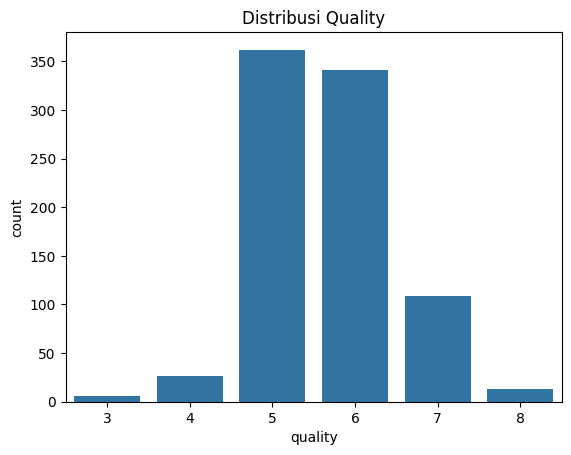

In [ ]:
sns.countplot(x=y)
plt.title("Distribusi Quality")
plt.show()

Pada bagian yang terakhir ini merupakan bagian visualisasi untuk mengvisualisasi hasil akhir.